# Classification Perfomance based on Explanations

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, abspath
from collections import Counter
import numpy as np
from os.path import join
sys.path.append("../..")


from config import DATA_DIR, ALL_GROUPS
from utils.classification_helpers import group_ihra_content, group_lexicon_content, map_lexicon_chapters_to_ihra_sections, flatten, count_items, compute_multilabel_prec_recall, plot_distribution_diff, plot_distribution_diff_pair

In [2]:
PROVIDER = "gemini"

In [3]:
bloomington = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_bloomington_label_1.feather"))
decoding = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_decoding_label_1.feather"))

In [4]:
bloomington.columns

Index(['comment_cleaned', 'id', 'classification_tax', 'explanation_tax',
       'classification_tax_ex', 'explanation_tax_ex', 'keyword',
       'ihra_section_1', 'ihra_section_2', 'ihra_sections',
       'classification_lexicon', 'explanation_lexicon',
       'classification_ihra_binary', 'classification_ihra_binary_cleaned',
       'classification_ihra_explanation',
       'classification_ihra_explanation_cleaned',
       'explanation_ihra_explanation', 'classification_no_kb',
       'classification_no_kb_cleaned', 'explanation_ihra_explanation_sections',
       'explanation_lexicon_chapters', 'explanation_lexicon_chapters_no',
       'explanation_lexicon_sections', 'explanation_tax_chapters',
       'explanation_tax_ex_chapters', 'explanation_tax_chapters_no',
       'explanation_tax_ex_chapters_no', 'explanation_tax_sections',
       'explanation_tax_ex_sections'],
      dtype='object')

In [5]:

column_name_renaming = {
    'classification_ihra_explanation_cleaned': 'IHRA_c',
    'explanation_ihra_explanation': 'IHRA_e',
    'classification_tax': 'TAX_c',
    'explanation_tax': 'TAX_e',
    'classification_tax_ex': 'TAX_EX_c',
    'explanation_tax_ex': 'TAX_EX_e',

    'classification_lexicon': 'LEXICON_c',
    'explanation_lexicon': 'LEXICON_e',
    'explanation_lexicon_chapters': 'LEXICON_e_chapters',
    'explanation_lexicon_chapters_no': 'LEXICON_e_chapters_no',
    'explanation_lexicon_sections': 'LEXICON_e_sections',

    'explanation_ihra_explanation_sections': 'IHRA_e_sections',
    'explanation_tax_chapters': 'TAX_e_chapters',
    'explanation_tax_chapters_no': 'TAX_e_chapters_no',
    'explanation_tax_ex_chapters': 'TAX_EX_e_chapters',
    'explanation_tax_ex_chapters_no': 'TAX_EX_e_chapters_no',
    'explanation_tax_sections': 'TAX_e_sections',
    'explanation_tax_ex_sections': 'TAX_EX_e_sections',
}
bloomington.rename(columns=column_name_renaming, inplace=True)
decoding.rename(columns=column_name_renaming, inplace=True)

REL_CLASS_COLS = column_name_renaming.values()

BLOOMINGTON_DATA_COLS = ['comment_cleaned', 'keyword', 'ihra_sections']
DECODING_DATA_COLS = ['comment_cleaned', 'comment_codes_all_list', 'comment_codes_all_chapters', 'comment_codes_all_sections']


In [6]:
bloomington.columns

Index(['comment_cleaned', 'id', 'TAX_c', 'TAX_e', 'TAX_EX_c', 'TAX_EX_e',
       'keyword', 'ihra_section_1', 'ihra_section_2', 'ihra_sections',
       'LEXICON_c', 'LEXICON_e', 'classification_ihra_binary',
       'classification_ihra_binary_cleaned', 'classification_ihra_explanation',
       'IHRA_c', 'IHRA_e', 'classification_no_kb',
       'classification_no_kb_cleaned', 'IHRA_e_sections', 'LEXICON_e_chapters',
       'LEXICON_e_chapters_no', 'LEXICON_e_sections', 'TAX_e_chapters',
       'TAX_EX_e_chapters', 'TAX_e_chapters_no', 'TAX_EX_e_chapters_no',
       'TAX_e_sections', 'TAX_EX_e_sections'],
      dtype='object')

# Bloomington

In [10]:
# Average number of codes per post given by human annotators
b_sections_count, b_sections_count_norm = count_items(bloomington["ihra_sections"])
sum(b_sections_count.values())/len(bloomington)

1.3003229278794401

### IHRA

In [7]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [8]:
len(bloomington_ihra)

1256

In [9]:
bloomington_ihra['overlap'] = bloomington_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_ihra['overlap'].mean()

np.float64(0.9004777070063694)

In [11]:
b_ihra_sections_count, b_ihra_sections_count_norm = count_items(bloomington_ihra["ihra_sections"])

In [12]:
# total sum of annotator sections
sum(b_ihra_sections_count.values())

1652

In [13]:
b_ihra_e_sections_count, b_ihra_e_sections_count_norm = count_items(bloomington_ihra["IHRA_e_sections"])

In [14]:
bloomington_ihra["ihra_sections_cnt"] = bloomington_ihra["ihra_sections"].map(len)
bloomington_ihra["IHRA_e_sections_cnt"] = bloomington_ihra["IHRA_e_sections"].map(len)
bloomington_ihra[["ihra_sections_cnt", "IHRA_e_sections_cnt"]].describe()

,ihra_sections_cnt,IHRA_e_sections_cnt
count,1256.000000,1256.000000
mean,1.315287,1.652866
std,0.474989,0.728831
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,2.000000
max,2.000000,5.000000


There are 1.32 codes/post by human annotators vs. 1.65 by model

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [15]:
compute_multilabel_prec_recall(bloomington_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,211,387,111,0.526066,0.286822
3,classic_power,525,726,449,0.855238,0.618457
1,israel,710,664,620,0.873239,0.933735
0,second_postholocaust,83,114,43,0.518072,0.377193


### TAX

In [17]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax.head()

bloomington_tax['overlap'] = bloomington_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax['overlap'].mean()

np.float64(0.9098712446351931)

In [18]:
bloomington_tax["ihra_sections_cnt"] = bloomington_tax["ihra_sections"].map(len)
bloomington_tax["tax_e_chapters_cnt"] = bloomington_tax["TAX_e_chapters"].map(len)

In [19]:
b_tax_sections_count, b_tax_sections_count_norm = count_items(bloomington_tax["ihra_sections"])

In [20]:
sum(b_tax_sections_count.values())

2153

In [21]:
b_tax_e_chapters_count, b_tax_e_chapters_count_norm = count_items(bloomington_tax["TAX_e_chapters"])

In [22]:
bloomington_tax.describe()

,overlap,ihra_sections_cnt,tax_e_chapters_cnt
count,1631.000000,1631.000000,1631.000000
mean,0.909871,1.320049,2.522379
std,0.286454,0.466638,1.389914
min,0.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,1.000000,2.000000,3.000000
max,1.000000,2.000000,9.000000


TAX produces 2.52 references to Lexicon chapters per post on average

In [23]:
b_tax_groups_count, b_tax_groups_count_norm = count_items(bloomington_tax["annotators_content_groups"], interpret_as_int=False)
b_tax_e_groups_count, b_tax_e_groups_count_norm = count_items(bloomington_tax["explanation_content_groups"], interpret_as_int=False)

In [24]:
b_tax_groups_count

Counter({'israel': 1042,
         'classic_power': 554,
         'aggressive': 223,
         'second_postholocaust': 104,
         None: 58})

In [25]:
b_tax_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

In [27]:
compute_multilabel_prec_recall(bloomington_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,223,423,143,0.641256,0.338061
3,classic_power,554,745,444,0.801444,0.595973
1,israel,1042,1018,968,0.928983,0.950884
0,second_postholocaust,104,389,81,0.778846,0.208226


### TAX EX

In [155]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex.head()

bloomington_tax_ex['overlap'] = bloomington_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax_ex['overlap'].mean()

np.float64(0.8628719275549805)

In [156]:
bloomington_tax_ex["ihra_sections_cnt"] = bloomington_tax_ex["ihra_sections"].map(len)
bloomington_tax_ex["tax_ex_e_chapters_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(len)

In [157]:
bloomington_tax_ex.describe()

,overlap,ihra_sections_cnt,tax_ex_e_chapters_cnt
count,1546.000000,1546.000000,1546.000000
mean,0.862872,1.324709,2.104140
std,0.344094,0.468418,1.229159
min,0.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,1.000000,2.000000,3.000000
max,1.000000,2.000000,9.000000


In [158]:
b_tax_ex_sections_count, b_tax_ex_sections_count_norm = count_items(bloomington_tax_ex["ihra_sections"])

In [159]:
sum(b_tax_ex_sections_count.values())

2048

In [160]:
b_tax_ex_e_chapters_count, b_tax_ex_e_chapters_count_norm = count_items(bloomington_tax_ex["TAX_EX_e_chapters"])

In [161]:
b_tax_ex_groups_count, b_tax_ex_groups_count_norm = count_items(bloomington_tax_ex["annotators_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_count, b_tax_ex_e_groups_count_norm = count_items(bloomington_tax_ex["explanation_content_groups"], interpret_as_int=False)

In [162]:
b_tax_ex_groups_count

Counter({'israel': 957,
         'classic_power': 556,
         'aggressive': 221,
         'second_postholocaust': 99,
         None: 55})

In [163]:
b_tax_ex_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_ex_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

In [38]:
compute_multilabel_prec_recall(bloomington_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,221,230,108,0.488688,0.469565
3,classic_power,556,813,453,0.814748,0.557196
1,israel,957,864,823,0.859979,0.952546
0,second_postholocaust,99,233,68,0.686869,0.291845


### LEXICON

In [165]:
bloomington_lexicon = bloomington[bloomington['LEXICON_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['LEXICON_e_chapters']]
bloomington_lexicon['annotators_content_groups'] = bloomington_lexicon['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_lexicon['explanation_content_groups'] = bloomington_lexicon['LEXICON_e_chapters'].map(group_lexicon_content)
bloomington_lexicon.head()

bloomington_lexicon['overlap'] = bloomington_lexicon.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_lexicon['overlap'].mean()

np.float64(0.8583280153158902)

In [166]:
bloomington_lexicon["ihra_sections_cnt"] = bloomington_lexicon["ihra_sections"].map(len)
bloomington_lexicon["lexicon_e_chapters_cnt"] = bloomington_lexicon["LEXICON_e_chapters"].map(len)

In [167]:
bloomington_lexicon.describe()

,overlap,ihra_sections_cnt,lexicon_e_chapters_cnt
count,1567.000000,1567.000000,1567.000000
mean,0.858328,1.324186,2.353542
std,0.348825,0.468219,1.313584
min,0.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,1.000000,2.000000,3.000000
max,1.000000,2.000000,11.000000


In [42]:
b_lexicon_sections_count, b_lexicon_sections_count_norm = count_items(bloomington_lexicon["ihra_sections"])

In [44]:
b_lexicon_e_chapters_count, b_lexicon_e_chapters_count_norm = count_items(bloomington_lexicon["LEXICON_e_chapters"])

In [45]:
b_lexicon_groups_count, b_lexicon_groups_count_norm = count_items(bloomington_lexicon["annotators_content_groups"], interpret_as_int=False)
b_lexicon_e_groups_count, b_lexicon_e_groups_count_norm = count_items(bloomington_lexicon["explanation_content_groups"], interpret_as_int=False)

In [46]:
b_lexicon_groups_count

Counter({'israel': 989,
         'classic_power': 544,
         'aggressive': 218,
         'second_postholocaust': 104,
         None: 56})

In [47]:
b_lexicon_groups_count = {key: value for key, value in b_lexicon_groups_count.items() if key in ALL_GROUPS}
b_lexicon_groups_count_norm = {key: value for key, value in b_lexicon_groups_count_norm.items() if key in ALL_GROUPS}

In [48]:
compute_multilabel_prec_recall(bloomington_lexicon, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,218,205,96,0.440367,0.468293
3,classic_power,544,963,460,0.845588,0.477674
1,israel,989,923,856,0.865521,0.927411
0,second_postholocaust,104,299,66,0.634615,0.220736


# Decoding

In [49]:
d_chapters_count, d_chapters_count_norm = count_items(decoding["comment_codes_all_chapters"])
sum(d_chapters_count.values())/len(decoding)

1.4783338931810548

### IHRA

Can be compared on the level of groups only

In [168]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]

In [169]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra.tail()

decoding_ihra['overlap'] = decoding_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_ihra['overlap'].mean()

np.float64(0.8049469964664311)

In [170]:
decoding_ihra["lexicon_chapters_cnt"] = decoding_ihra["comment_codes_all_chapters"].map(len)
decoding_ihra["IHRA_e_sections_cnt"] = decoding_ihra["IHRA_e_sections"].map(len)

In [172]:
decoding_ihra.describe()

,overlap,lexicon_chapters_cnt,IHRA_e_sections_cnt
count,1415.000000,1415.000000,1415.000000
mean,0.804947,1.604240,1.626148
std,0.396382,1.000132,0.769482
min,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,2.000000,2.000000
max,1.000000,8.000000,5.000000


In [56]:
d_ihra_chapters_count, d_ihra_chapters_count_norm = count_items(decoding_ihra["comment_codes_all_chapters"])
#sum(d_ihra_chapters_count.values())

In [57]:
d_ihra_e_sections_count, d_ihra_e_sections_count_norm = count_items(decoding_ihra["IHRA_e_sections"])

In [58]:
d_ihra_groups_count, d_ihra_groups_count_norm = count_items(decoding_ihra["annotators_content_groups"], interpret_as_int=False)
d_ihra_e_groups_count, d_ihra_e_groups_count_norm = count_items(decoding_ihra["explanation_content_groups"], interpret_as_int=False)

In [59]:
d_ihra_groups_count

Counter({'israel': 771,
         'classic_power': 696,
         'second_postholocaust': 227,
         'aggressive': 84})

In [60]:
d_ihra_e_groups_count

Counter({'israel': 746,
         'classic_power': 678,
         'aggressive': 457,
         'second_postholocaust': 263,
         None: 1})

In [61]:
d_ihra_e_groups_count = {key: value for key, value in d_ihra_e_groups_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_count_norm = {key: value for key, value in d_ihra_e_groups_count_norm.items() if key in ALL_GROUPS}

In [62]:
compute_multilabel_prec_recall(decoding_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,84,457,56,0.666667,0.122538
3,classic_power,696,678,484,0.695402,0.713864
1,israel,771,746,611,0.792477,0.819035
0,second_postholocaust,227,263,62,0.273128,0.235741


### TAX

In [173]:
decoding.columns

Index(['comment_cleaned', 'id', 'TAX_c', 'TAX_e', 'TAX_EX_c', 'TAX_EX_e',
       'discourse', 'comment_level', 'comment_codes_all', 'source_outlet',
       'LEXICON_c', 'LEXICON_e', 'classification_ihra_binary',
       'classification_ihra_binary_cleaned', 'classification_ihra_explanation',
       'IHRA_c', 'IHRA_e', 'classification_no_kb',
       'classification_no_kb_cleaned', 'IHRA_e_sections', 'LEXICON_e_chapters',
       'LEXICON_e_chapters_no', 'LEXICON_e_sections', 'comment_codes_all_list',
       'comment_codes_all_chapters', 'comment_codes_all_sections',
       'TAX_e_chapters', 'TAX_EX_e_chapters', 'TAX_e_chapters_no',
       'TAX_EX_e_chapters_no', 'TAX_e_sections', 'TAX_EX_e_sections'],
      dtype='object')

In [174]:
decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]

In [175]:
decoding_tax.columns

Index(['comment_cleaned', 'comment_codes_all_list',
       'comment_codes_all_chapters', 'comment_codes_all_sections', 'TAX_e',
       'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections'],
      dtype='object')

In [176]:
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['annotators_content_groups']

0                     [israel]
1                     [israel]
2                     [israel]
3                     [israel]
4              [classic_power]
                 ...          
2971                  [israel]
2973    [second_postholocaust]
2974                  [israel]
2975                  [israel]
2976                  [israel]
Name: annotators_content_groups, Length: 2579, dtype: object

In [177]:
decoding_tax['TAX_e_chapters']

0                   [29]
1                   [29]
2                   [29]
3           [31, 29, 33]
4        [31, 32, 36, 5]
              ...       
2971            [34, 36]
2973    [36, 38, 25, 42]
2974            [34, 36]
2975                [36]
2976                [29]
Name: TAX_e_chapters, Length: 2579, dtype: object

In [178]:
decoding_tax[decoding_tax['TAX_e_chapters'].isna()]

,comment_cleaned,comment_codes_all_list,comment_codes_all_chapters,comment_codes_all_sections,TAX_e,TAX_e_chapters,TAX_e_chapters_no,TAX_e_sections,annotators_content_groups


In [179]:
decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax.head()

decoding_tax['overlap'] = decoding_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax['overlap'].mean()

np.float64(0.8406359053896859)

In [180]:
decoding_tax["tax_chapters_cnt"] = decoding_tax["comment_codes_all_chapters"].map(len)
decoding_tax["tax_e_chapters_cnt"] = decoding_tax["TAX_e_chapters"].map(len)
decoding_tax[["tax_chapters_cnt", "tax_e_chapters_cnt"]].describe()

,tax_chapters_cnt,tax_e_chapters_cnt
count,2579.000000,2579.000000
mean,1.511826,2.594804
std,0.891384,1.434038
min,0.000000,0.000000
25%,1.000000,1.500000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,8.000000,11.000000


#### Group level

In [81]:
d_tax_groups_count, d_tax_groups_count_norm = count_items(decoding_tax["annotators_content_groups"], interpret_as_int=False)
d_tax_e_groups_count, d_tax_e_groups_count_norm = count_items(decoding_tax["explanation_content_groups"], interpret_as_int=False)

In [82]:
compute_multilabel_prec_recall(decoding_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,98,435,67,0.683673,0.154023
3,classic_power,1158,815,597,0.515544,0.732515
1,israel,1521,1969,1456,0.957265,0.739462
0,second_postholocaust,430,645,283,0.658140,0.438760


### TAX_EX

In [85]:
decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex.head()

decoding_tax_ex['overlap'] = decoding_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax_ex['overlap'].mean()

np.float64(0.8884245716673631)

In [86]:
decoding_tax_ex["tax_ex_chapters_cnt"] = decoding_tax_ex["comment_codes_all_chapters"].map(len)
decoding_tax_ex["tax_ex_e_chapters_cnt"] = decoding_tax_ex["TAX_EX_e_chapters"].map(len)
decoding_tax_ex[["tax_ex_chapters_cnt", "tax_ex_e_chapters_cnt"]].describe()

,tax_ex_chapters_cnt,tax_ex_e_chapters_cnt
count,2393.000000,2393.000000
mean,1.535311,2.201839
std,0.912397,1.283662
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,8.000000,11.000000


In [87]:
d_tax_ex_chapters_count, d_tax_ex_chapters_count_norm = count_items(decoding_tax_ex["comment_codes_all_chapters"])
sum(d_tax_ex_chapters_count.values())

3674

#### Group level

In [97]:
d_tax_ex_groups_count, d_tax_ex_groups_count_norm = count_items(decoding_tax_ex["annotators_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_count, d_tax_ex_e_groups_count_norm = count_items(decoding_tax_ex["explanation_content_groups"], interpret_as_int=False)

In [98]:
compute_multilabel_prec_recall(decoding_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,99,268,62,0.626263,0.231343
3,classic_power,1123,1134,834,0.742654,0.735450
1,israel,1388,1587,1272,0.916427,0.801512
0,second_postholocaust,378,407,240,0.634921,0.589681


## LEXICON

In [100]:
decoding_lexicon = decoding[decoding['LEXICON_c']=='Yes'][DECODING_DATA_COLS + ['LEXICON_e', 'LEXICON_e_chapters', 'LEXICON_e_chapters_no', 'LEXICON_e_sections']]
decoding_lexicon['annotators_content_groups'] = decoding_lexicon['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_lexicon['explanation_content_groups'] = decoding_lexicon['LEXICON_e_chapters'].map(group_lexicon_content)
decoding_lexicon.head()

decoding_lexicon['overlap'] = decoding_lexicon.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_lexicon['overlap'].mean()

np.float64(0.9159431728492502)

In [101]:
decoding_lexicon["lexicon_chapters_cnt"] = decoding_lexicon["comment_codes_all_chapters"].map(len)
decoding_lexicon["lexicon_e_chapters_cnt"] = decoding_lexicon["LEXICON_e_chapters"].map(len)
decoding_lexicon[["lexicon_chapters_cnt", "lexicon_e_chapters_cnt"]].describe()

,lexicon_chapters_cnt,lexicon_e_chapters_cnt
count,2534.000000,2534.000000
mean,1.529203,2.623520
std,0.906035,1.721286
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,8.000000,15.000000


#### Group level

In [112]:
d_lexicon_groups_count, d_lexicon_groups_count_norm = count_items(decoding_lexicon["annotators_content_groups"], interpret_as_int=False)
d_lexicon_e_groups_count, d_lexicon_e_groups_count_norm = count_items(decoding_lexicon["explanation_content_groups"], interpret_as_int=False)

In [113]:
compute_multilabel_prec_recall(decoding_lexicon, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,99,337,83,0.838384,0.246291
3,classic_power,1186,1499,1004,0.846543,0.669780
1,israel,1434,1689,1330,0.927476,0.787448
0,second_postholocaust,436,569,324,0.743119,0.569420


# DATASET UNION

## IHRA

In [115]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra["dataset_id"] = "b"
bloomington_ihra = bloomington_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
# decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=1948])))
decoding_ihra["dataset_id"] = "d"
decoding_ihra = decoding_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_ihra = pd.concat([bloomington_ihra, decoding_ihra], ignore_index=True)
df_union_ihra.sample(2)


,comment_cleaned,annotators_content_groups,IHRA_e,explanation_content_groups,dataset_id
569,Why should people like Jews who support a sett...,[israel],The post contains antisemitic speech by holdin...,"[second_postholocaust, israel]",b
64,It's literally none of your business what Pale...,[israel],The post refers to Israel as an 'illegitimate ...,[israel],b


In [116]:
mask = df_union_ihra["explanation_content_groups"].map(lambda x: None in x)
for index, row in df_union_ihra[mask].iterrows():
    print(row['IHRA_e_sections'])
    print(row['comment_cleaned'])
    print(row['IHRA_e'])
    print(row["dataset_id"])

In [117]:
df_union_ihra['overlap'] = df_union_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_ihra['overlap'].mean()



np.float64(0.8498689629352303)

In [118]:
df_union_ihra["annotator_content_cnt"] = df_union_ihra["annotators_content_groups"].map(len)
df_union_ihra["model_content_count"] = df_union_ihra["explanation_content_groups"].map(len)
df_union_ihra[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2671.000000,2671.00000
mean,1.238113,1.51067
std,0.487507,0.65212
min,0.000000,0.00000
25%,1.000000,1.00000
50%,1.000000,1.00000
75%,1.000000,2.00000
max,4.000000,4.00000


#### Group level

In [119]:
u_ihra_groups_count, u_ihra_groups_count_norm = count_items(df_union_ihra["annotators_content_groups"], interpret_as_int=False)
u_ihra_e_groups_count, u_ihra_e_groups_count_norm = count_items(df_union_ihra["explanation_content_groups"], interpret_as_int=False)

In [120]:
df_union_ihra["explanation_content_groups"].value_counts()

explanation_content_groups
[israel]                                                     911
[classic_power]                                              465
[aggressive, classic_power]                                  459
[israel, classic_power]                                      179
[israel, aggressive]                                         102
[second_postholocaust, classic_power]                        100
[aggressive]                                                  91
[israel, aggressive, classic_power]                           85
[second_postholocaust]                                        59
[second_postholocaust, israel, classic_power]                 57
[second_postholocaust, israel]                                54
[second_postholocaust, aggressive, classic_power]             50
[second_postholocaust, aggressive]                            35
[second_postholocaust, israel, aggressive]                    13
[second_postholocaust, israel, aggressive, classic_power]      

In [121]:
df_union_ihra.columns

Index(['comment_cleaned', 'annotators_content_groups', 'IHRA_e',
       'explanation_content_groups', 'dataset_id', 'overlap',
       'annotator_content_cnt', 'model_content_count'],
      dtype='object')

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [122]:
compute_multilabel_prec_recall(df_union_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,295,844,167,0.566102,0.197867
3,classic_power,1221,1404,933,0.764128,0.664530
1,israel,1481,1410,1231,0.831195,0.873050
0,second_postholocaust,310,377,105,0.338710,0.278515


## TAX

In [123]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e', 'TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax["dataset_id"] = "b"
bloomington_tax = bloomington_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax["dataset_id"] = "d"
decoding_tax = decoding_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax = pd.concat([bloomington_tax, decoding_tax], ignore_index=True)
df_union_tax.sample(2)

,comment_cleaned,annotators_content_groups,TAX_e,explanation_content_groups,dataset_id
24,"Oooh, a big brave Israeli solder overcoming ov...",[israel],The text draws an explicit comparison between ...,[israel],b
2645,"MSM is owned by the Zionists so yeah, I guess ...",[classic_power],The statement propagates antisemitic conspirac...,"[second_postholocaust, classic_power]",d


In [125]:
bloomington_tax['annotators_content_groups'].value_counts()

annotators_content_groups
[israel]                                 793
[classic_power]                          381
[israel, classic_power]                  128
[aggressive]                             106
[israel, aggressive]                      84
[second_postholocaust]                    45
[second_postholocaust, israel]            37
[aggressive, classic_power]               28
[second_postholocaust, classic_power]     17
[]                                         7
[second_postholocaust, aggressive]         5
Name: count, dtype: int64

In [126]:
df_union_tax['overlap'] = df_union_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax['overlap'].mean()

np.float64(0.867458432304038)

In [127]:
df_union_tax["annotator_content_cnt"] = df_union_tax["annotators_content_groups"].map(len)
df_union_tax["model_content_count"] = df_union_tax["explanation_content_groups"].map(len)
df_union_tax[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,4210.000000,4210.000000
mean,1.218527,1.529454
std,0.467259,0.721797
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [128]:
u_tax_groups_count, u_tax_groups_count_norm = count_items(df_union_tax["annotators_content_groups"], interpret_as_int=False)
u_tax_e_groups_count, u_tax_e_groups_count_norm = count_items(df_union_tax["explanation_content_groups"], interpret_as_int=False)
print(u_tax_groups_count)
print(u_tax_e_groups_count)

Counter({'israel': 2563, 'classic_power': 1712, 'second_postholocaust': 534, 'aggressive': 321})
Counter({'israel': 2987, 'classic_power': 1560, 'second_postholocaust': 1034, 'aggressive': 858})


In [129]:
# get all unique items across all lists
all_items = set(item for sublist in df_union_tax["annotators_content_groups"] if isinstance(sublist, list) for item in sublist)
print(all_items)

{'second_postholocaust', 'israel', 'aggressive', 'classic_power'}


In [130]:
for item in all_items:
    result = group_ihra_content(item)  # or group_lexicon_content, whichever is relevant here
    if result is None:
        print(f"Input '{item}' maps to None")

Input 'second_postholocaust' maps to None
Input 'israel' maps to None
Input 'aggressive' maps to None
Input 'classic_power' maps to None


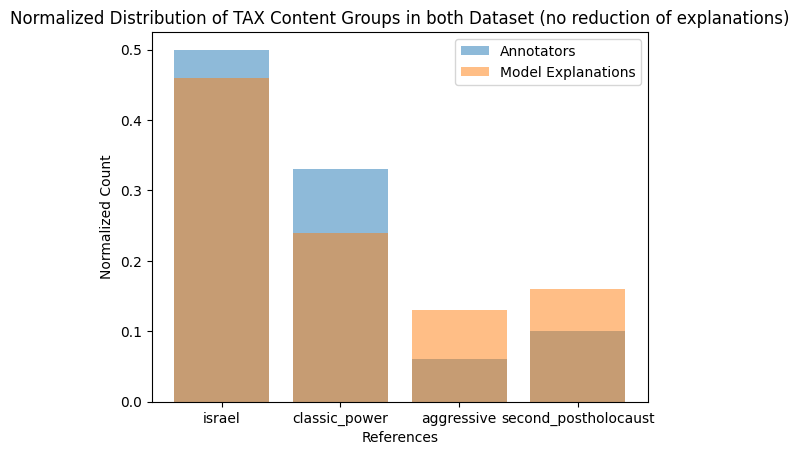

In [131]:
plot_distribution_diff(
    u_tax_groups_count_norm, 
    u_tax_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [132]:
compute_multilabel_prec_recall(df_union_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,321,858,210,0.654206,0.244755
3,classic_power,1712,1560,1041,0.608061,0.667308
1,israel,2563,2987,2424,0.945767,0.811517
0,second_postholocaust,534,1034,364,0.681648,0.352031


## TAX_EX

In [133]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex["dataset_id"] = "b"
bloomington_tax_ex = bloomington_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex["dataset_id"] = "d"
decoding_tax_ex = decoding_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_tax_ex = pd.concat([bloomington_tax_ex, decoding_tax_ex], ignore_index=True)
df_union_tax_ex.sample(2)

,comment_cleaned,annotators_content_groups,TAX_EX_e,explanation_content_groups,dataset_id
1450,The ZioNazi US will refuse and spineless Itali...,"[israel, classic_power]",The term 'ZioNazi' explicitly draws a Nazi ana...,"[israel, classic_power]",b
432,Boycott apartheid Israel. Pass it on.,[israel],The post is antisemitic as it labels Israel as...,[israel],b


In [134]:
decoding_lexicon = decoding[decoding['LEXICON_c']=='Yes'][DECODING_DATA_COLS + ['LEXICON_e', 'LEXICON_e_chapters', 'LEXICON_e_chapters_no', 'LEXICON_e_sections']]
decoding_lexicon['annotators_content_groups'] = decoding_lexicon['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_lexicon['explanation_content_groups'] = decoding_lexicon['LEXICON_e_chapters'].map(group_lexicon_content)
decoding_lexicon.head()

decoding_lexicon['overlap'] = decoding_lexicon.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_lexicon['overlap'].mean()

np.float64(0.9159431728492502)

In [135]:
df_union_tax_ex['overlap'] = df_union_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax_ex['overlap'].mean()

np.float64(0.8783955318608784)

In [136]:
df_union_tax_ex["annotator_content_cnt"] = df_union_tax_ex["annotators_content_groups"].map(len)
df_union_tax_ex["model_content_count"] = df_union_tax_ex["explanation_content_groups"].map(len)
df_union_tax_ex[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,3939.000000,3939.000000
mean,1.223915,1.405433
std,0.473929,0.598272
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [137]:
u_tax_ex_groups_count, u_tax_ex_groups_count_norm = count_items(df_union_tax_ex["annotators_content_groups"], interpret_as_int=False)
u_tax_ex_e_groups_count, u_tax_ex_e_groups_count_norm = count_items(df_union_tax_ex["explanation_content_groups"], interpret_as_int=False)
print(u_tax_ex_groups_count)

Counter({'israel': 2345, 'classic_power': 1679, 'second_postholocaust': 477, 'aggressive': 320})


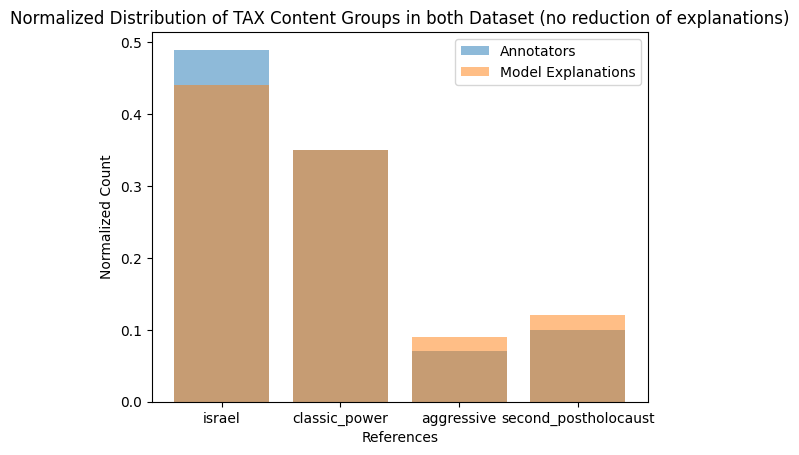

In [138]:
plot_distribution_diff(
    u_tax_ex_groups_count_norm, 
    u_tax_ex_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [139]:
compute_multilabel_prec_recall(df_union_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,320,498,170,0.531250,0.341365
3,classic_power,1679,1947,1287,0.766528,0.661017
1,israel,2345,2451,2095,0.893390,0.854753
0,second_postholocaust,477,640,308,0.645702,0.481250


## LEXICON

In [ ]:
bloomington_lexicon = bloomington[bloomington['LEXICON_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['LEXICON_e_chapters']]
bloomington_lexicon['annotators_content_groups'] = bloomington_lexicon['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_lexicon['explanation_content_groups'] = bloomington_lexicon['LEXICON_e_chapters'].map(group_lexicon_content)
bloomington_lexicon["dataset_id"] = "b"
bloomington_lexicon = bloomington_lexicon[["comment_cleaned", "annotators_content_groups", "LEXICON_e", "explanation_content_groups", "dataset_id"]]

decoding_lexicon = decoding[decoding['LEXICON_c']=='Yes'][DECODING_DATA_COLS + ['LEXICON_e', 'LEXICON_e_chapters', 'LEXICON_e_chapters_no', 'LEXICON_e_sections']]
decoding_lexicon['annotators_content_groups'] = decoding_lexicon['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_lexicon['explanation_content_groups'] = decoding_lexicon['LEXICON_e_chapters'].map(group_lexicon_content)
decoding_lexicon["dataset_id"] = "d"
decoding_lexicon = decoding_lexicon[["comment_cleaned", "annotators_content_groups", "LEXICON_e", "explanation_content_groups", "dataset_id"]]

# Now union — both dataframes already have annotators_content_groups
df_union_lexicon = pd.concat([bloomington_lexicon, decoding_lexicon], ignore_index=True)

In [ ]:
bloomington_lexicon['overlap'] = bloomington_lexicon.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_lexicon['overlap'].mean()

np.float64(0.8583280153158902)

In [142]:
bloomington_lexicon["ihra_sections_cnt"] = bloomington_lexicon["ihra_sections"].map(len)
bloomington_lexicon["lexicon_e_chapters_cnt"] = bloomington_lexicon["LEXICON_e_chapters"].map(len)

In [143]:
b_lexicon_sections_count, b_lexicon_sections_count_norm = count_items(bloomington_lexicon["ihra_sections"])

In [144]:
sum(b_lexicon_sections_count.values())

2075

In [145]:
b_lexicon_e_chapters_count, b_lexicon_e_chapters_count_norm = count_items(bloomington_lexicon["LEXICON_e_chapters"])

In [146]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [147]:
bloomington_lexicon["Lexicon_e_chapters_max_2"] = bloomington_lexicon["LEXICON_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_lexicon["Lexicon_e_chapters_max_2_cnt"] = bloomington_lexicon["Lexicon_e_chapters_max_2"].map(len)
bloomington_lexicon["Lexicon_e_chapters_same"] = bloomington_lexicon.apply(lambda x: reduce_to_same_number(x, to_reduce_col="LEXICON_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_lexicon["Lexicon_e_chapters_same_cnt"] = bloomington_lexicon["Lexicon_e_chapters_same"].map(len)
bloomington_lexicon[["ihra_sections_cnt", "lexicon_e_chapters_cnt", "Lexicon_e_chapters_max_2_cnt", "Lexicon_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,lexicon_e_chapters_cnt,Lexicon_e_chapters_max_2_cnt,Lexicon_e_chapters_same_cnt
count,1567.000000,1567.000000,1567.000000,1567.000000
mean,1.324186,2.353542,1.702616,1.242502
std,0.468219,1.313584,0.464183,0.436116
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,1.000000
max,2.000000,11.000000,2.000000,2.000000


In [ ]:
bloomington_lexicon['explanation_same_content_groups'] = bloomington_lexicon['Lexicon_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_lexicon_groups_count, b_lexicon_groups_count_norm = count_items(bloomington_lexicon["annotators_content_groups"], interpret_as_int=False)
b_lexicon_e_groups_count, b_lexicon_e_groups_count_norm = count_items(bloomington_lexicon["explanation_content_groups"], interpret_as_int=False)
b_lexicon_e_groups_same_count, b_lexicon_e_groups_same_count_norm = count_items(bloomington_lexicon["explanation_same_content_groups"], interpret_as_int=False)

In [150]:
b_lexicon_groups_count

Counter({'israel': 989,
         'classic_power': 544,
         'aggressive': 218,
         'second_postholocaust': 104})

In [151]:
b_lexicon_groups_count = {key: value for key, value in b_lexicon_groups_count.items() if key in ALL_GROUPS}
b_lexicon_groups_count_norm = {key: value for key, value in b_lexicon_groups_count_norm.items() if key in ALL_GROUPS}

In [153]:
compute_multilabel_prec_recall(bloomington_lexicon, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
2,aggressive,218,205,96,0.440367,0.468293
3,classic_power,544,963,460,0.845588,0.477674
1,israel,989,923,856,0.865521,0.927411
0,second_postholocaust,104,299,66,0.634615,0.220736
